#Task 3: Perceptron Algorithm for 3 vs 5 Classification.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
df_3_5 = pd.read_csv("../datasets/mnist_3_and_5.csv")
X = df_3_5.drop("label", axis=1).values  # Features (pixel values)
y = df_3_5["label"].values  # Labels (0 or 1)

print("Feature Matrix (X):")
print(X)
print("Labels (y):")
print(y)

Feature Matrix (X):
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Labels (y):
[5 3 3 ... 3 3 5]


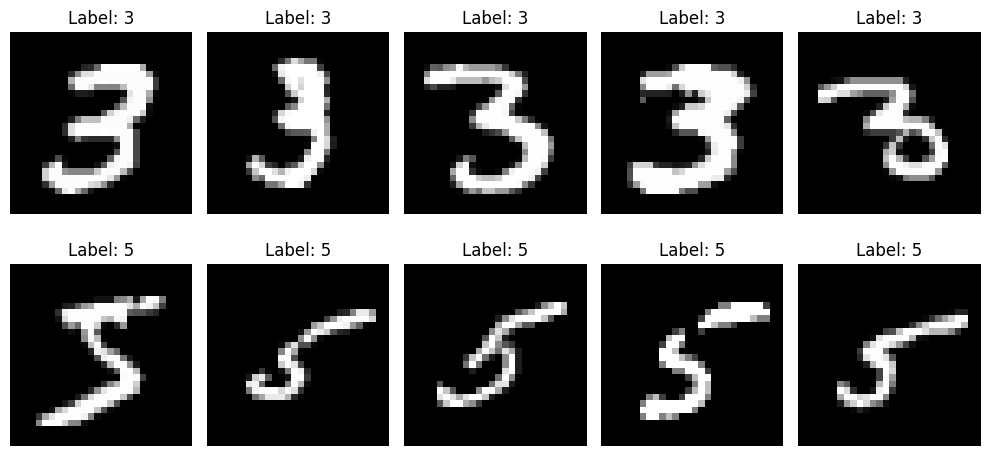

In [30]:
images_3 = X[y == 3]  # Images corresponding to label 3
images_5 = X[y == 5]  # Images corresponding to label 5

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if(len(images_3) >= 5 and len(images_5) >= 5):
    for i in range(5):
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap='gray')
        axes[0, i].set_title(f"Label: 3")
        axes[0, i].axis('off')

        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap='gray')
        axes[1, i].set_title(f"Label: 5")
        axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()


In [31]:
weights = np.zeros(X.shape[1]) # 784 weights (one for each pixel)
bias = 0
learning_rate = 0.1
epochs = 100

In [ ]:
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 5, 3)  # Step function - predict 5 or 3
    return y_pred_all

In [33]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.
        Parameters:
        - X: Features (input data) as a numpy array of shape (n_samples, n_features)
        - y: Labels (true output) as a numpy array of shape (n_samples,)
        - weights: Initial weights as a numpy array of shape (n_features,)
        - bias: Initial bias value (scalar)
        - learning_rate: Learning rate for weight updates (default is 0.1)
        - epochs: Number of iterations to train the model (default is 100)
        Returns:
        - weights: Updated weights after training
        - bias: Updated bias after training
        - accuracy: Total correct prediction.
    """

    for epoch in range(epochs):
        for i in range(X.shape[0]):
            y_pred = decision_function(X[i], weights, bias)
            error = y[i] - y_pred
            weights += learning_rate * error * X[i]  # Update weights
            bias += learning_rate * error  # Update bias

    y_pred_all = decision_function(X, weights, bias)
    accuracy = np.sum(y_pred_all == y) / len(y)  # Calculate accuracy
    return weights, bias, accuracy


In [34]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate, epochs)
print(f"Trained Weights: {weights}")
print(f"Trained Bias: {bias}")
print(f"Training Accuracy: {accuracy * 100:.2f}%")

Trained Weights: [0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00 0.000000e+00
 0.000000e+00 2.280000e+03 5.060000e+03 2.380000e+03 0.000000e+00
 2.980000e+03 7.900000e+03 1.526000e+04 8.260000e+03 4.0200

Final Accuracy: 0.0000


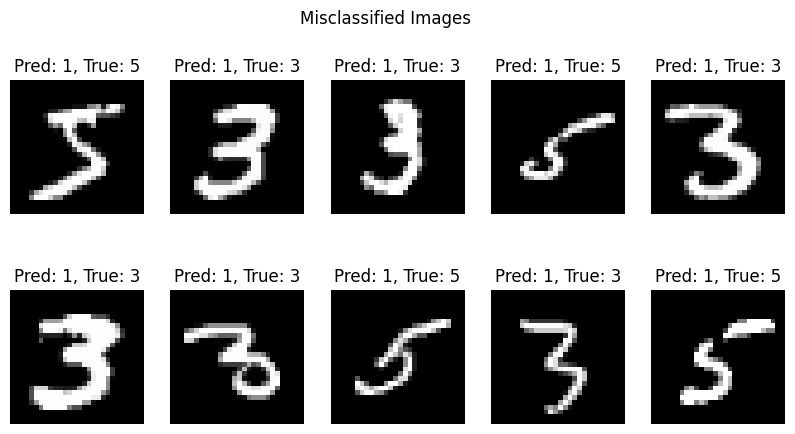

In [ ]:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 5, 3)  # Step function to get binary predictions (3 or 5)
# Calculate final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")
# Step 5: Visualize Misclassified Images
misclassified_idx = np.where(y_pred != y)[0]
if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):  # Show 10 misclassified images
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images")
    plt.show()
else:
    print("All images were correctly classified!")
